# scTGCL

**scTGCL** (Single-cell Transformer Graph Contrastive Learning) is a transformer-based
autoencoder trained with a contrastive objective to learn a low-dimensional latent
representation of single-cell RNA-seq profiles.

This notebook demonstrates the full pipeline on the **PBMC** dataset:

1. Load the preprocessed `data/pbmc.h5ad` file.
2. Train the scTGCL model.
3. Cluster the learned latent space with K-Means and report **CA, NMI, ARI** and **training time**.
4. Visualize the latent space with **UMAP**, colored by true cell types and predicted clusters.

## 1. Imports & Setup

In [1]:
import time
import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader

# scTGCL project modules
from config import get_config
from utils import setup_seed, scRNASeqDataset, evaluate_clustering
from scTGCL import scTGCL
from main import train_model

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

In [2]:
# ---- Configuration ----
DATA_PATH = 'data/pbmc.h5ad'

config = get_config()
# Feel free to lower `epochs` for an even quicker demo; the default reproduces the paper setup.
config['epochs'] = 200

setup_seed(config['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print('Configuration:')
for k, v in config.items():
    print(f'  {k}: {v}')

Using device: cuda
Configuration:
  embed_dim: 512
  num_heads: 8
  latent_dim: 64
  dropout: 0.3
  mask_prob: 0.25
  attention_mask_prob: 0.35
  lambda_recon: 6
  lambda_impute: 1
  lambda_contrast: 0.8
  temperature: 0.5
  lr: 0.001
  weight_decay: 0.001
  epochs: 200
  batch_size: 512
  seed: 42
  save_dir: results


## 2. Load the PBMC Dataset

The number of clusters is derived directly from the label column, exactly as in `main.py`.

In [3]:
adata = sc.read_h5ad(DATA_PATH)
X_all = adata.X
y_raw = adata.obs['cell_type'].values

# Encode string/byte labels to integers and derive the number of clusters
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(pd.DataFrame(y_raw).values.ravel())
config['n_clusters'] = len(label_encoder.classes_)

print(f'Expression matrix : {X_all.shape[0]} cells x {X_all.shape[1]} genes')
print(f'Number of clusters: {config["n_clusters"]}')
print('\nCell type distribution:')
print(pd.Series(y_raw).value_counts())

Expression matrix : 4340 cells x 2500 genes
Number of clusters: 8

Cell type distribution:
1.0    1294
2.0     708
3.0     611
4.0     462
5.0     453
6.0     376
7.0     297
8.0     139
Name: count, dtype: int64


## 3. Train / Test Split & DataLoaders

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=config['seed'], stratify=y_all
)

train_loader = DataLoader(scRNASeqDataset(X_train, y_train),
                          batch_size=config['batch_size'], shuffle=True)
test_loader = DataLoader(scRNASeqDataset(X_test, y_test),
                         batch_size=config['batch_size'], shuffle=False)

print(f'Train cells: {len(X_train)} | Test cells: {len(X_test)}')

Train cells: 3472 | Test cells: 868


## 4. Build the Model

In [5]:
model = scTGCL(
    input_dim=X_all.shape[1],
    embed_dim=config['embed_dim'],
    num_heads=config['num_heads'],
    latent_dim=config['latent_dim'],
    dropout=config['dropout'],
    mask_prob=config['mask_prob'],
    attention_mask_prob=config['attention_mask_prob'],
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

Model parameters: 13,839,620


## 5. Train the Model

`train_model` returns the best latent representation (lowest test reconstruction loss),
the corresponding labels, and the total training time.

In [6]:
best_latent, best_labels, training_time = train_model(
    model, train_loader, test_loader, config, device
)
print(f'\nLatent representation shape: {best_latent.shape}')


Starting Training...
Loss Weights: Recon=6, Impute=1, Contrast=0.8
Epoch 10/200: Total=51.4836 (Recon=2.7015, Impute=2.7398, Contrast=40.6688), Test=0.7756, Time=1.52s
Epoch 20/200: Total=50.0407 (Recon=2.6357, Impute=2.6656, Contrast=39.4510), Test=0.7546, Time=2.75s
Epoch 30/200: Total=49.2466 (Recon=2.6145, Impute=2.6387, Contrast=38.6514), Test=0.7450, Time=3.87s
Epoch 40/200: Total=48.9996 (Recon=2.5931, Impute=2.6214, Contrast=38.5243), Test=0.7401, Time=5.01s
Epoch 50/200: Total=48.8458 (Recon=2.5741, Impute=2.6089, Contrast=38.4905), Test=0.7394, Time=6.10s
Epoch 60/200: Total=48.5987 (Recon=2.5550, Impute=2.5809, Contrast=38.3598), Test=0.7321, Time=7.20s
Epoch 70/200: Total=48.4158 (Recon=2.5488, Impute=2.5764, Contrast=38.1832), Test=0.7327, Time=8.30s
Epoch 80/200: Total=48.1885 (Recon=2.5387, Impute=2.5640, Contrast=37.9905), Test=0.7281, Time=9.37s
Epoch 90/200: Total=47.9810 (Recon=2.5233, Impute=2.5458, Contrast=37.8691), Test=0.7263, Time=10.40s
Epoch 100/200: Total=4

## 6. Evaluate — CA, NMI, ARI & Training Time

K-Means is run on the learned latent space, and clustering quality is measured against
the ground-truth cell types.

In [7]:
kmeans = KMeans(n_clusters=config['n_clusters'], random_state=config['seed'], n_init=20)
pred_labels = kmeans.fit_predict(best_latent)

acc, nmi, ari = evaluate_clustering(best_labels, pred_labels)

results = pd.DataFrame({
    'Metric': ['Clustering Accuracy (CA)', 'NMI', 'ARI', 'Training time (s)'],
    'Value':  [f'{acc:.4f}', f'{nmi:.4f}', f'{ari:.4f}', f'{training_time:.2f}'],
})
print('=' * 45)
print(f'   scTGCL results on PBMC ({config["n_clusters"]} clusters)')
print('=' * 45)
results

   scTGCL results on PBMC (8 clusters)


,Metric,Value
0,Clustering Accuracy (CA),0.8422
1,NMI,0.7946
2,ARI,0.7819
3,Training time (s),22.76


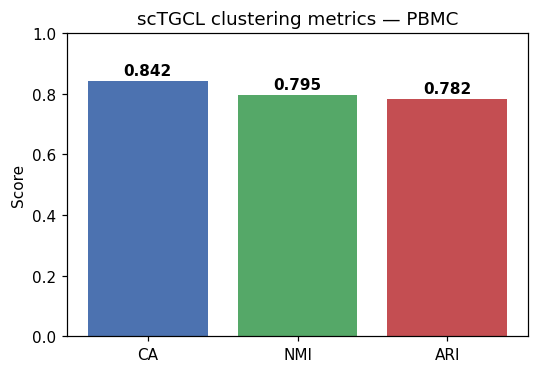

In [8]:
# Bar chart of the three clustering metrics
fig, ax = plt.subplots(figsize=(5, 3.5))
names = ['CA', 'NMI', 'ARI']
vals = [acc, nmi, ari]
bars = ax.bar(names, vals, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title(f'scTGCL clustering metrics — PBMC')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. UMAP Visualization of the Latent Space

We project the learned latent embeddings to 2D with UMAP and color the cells by their
**true cell type** (left) and the **predicted K-Means cluster** (right).

In [9]:
import umap

reducer = umap.UMAP(n_components=2, random_state=config['seed'])
embedding_2d = reducer.fit_transform(best_latent)
print(f'UMAP embedding shape: {embedding_2d.shape}')

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (868, 2)


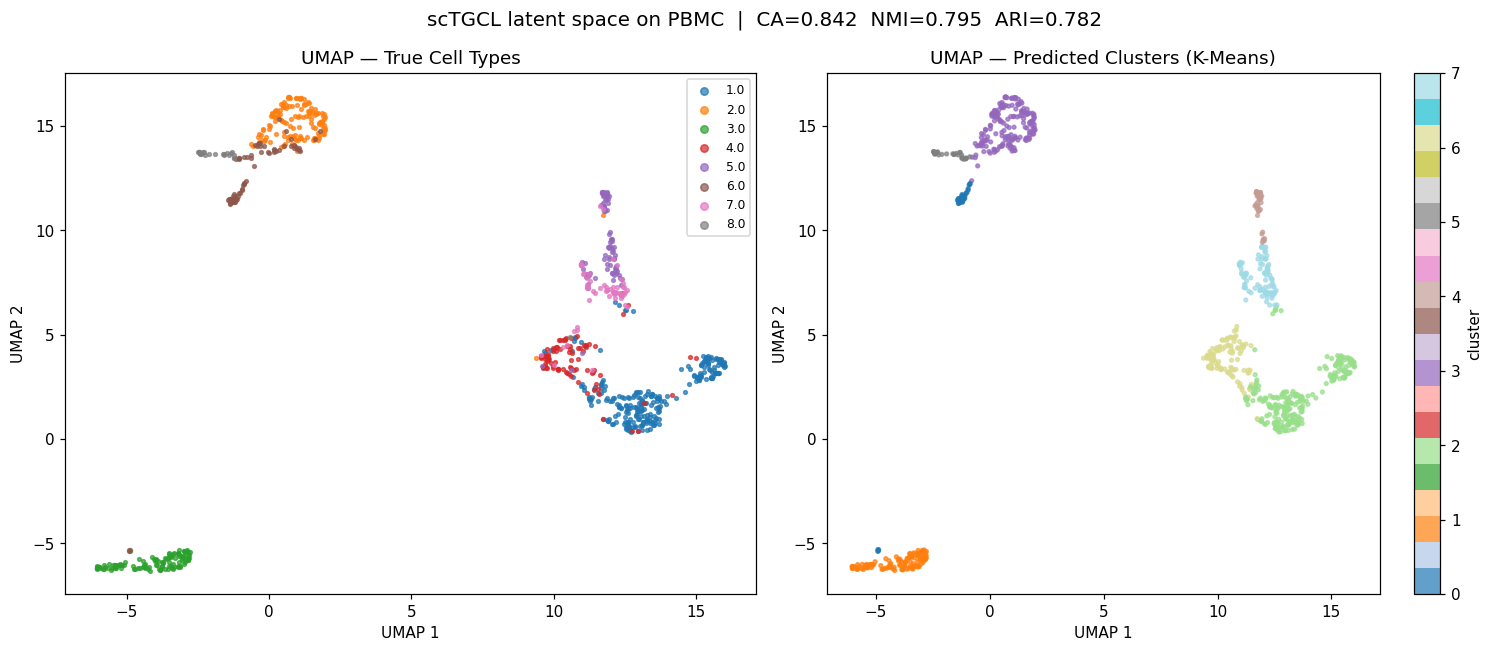

In [10]:
true_names = label_encoder.inverse_transform(best_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Colored by true cell type ---
for lab in np.unique(true_names):
    m = true_names == lab
    axes[0].scatter(embedding_2d[m, 0], embedding_2d[m, 1], s=6, alpha=0.7, label=str(lab))
axes[0].set_title('UMAP — True Cell Types')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(markerscale=2, fontsize=8, loc='best')

# --- Colored by predicted K-Means cluster ---
sc_plot = axes[1].scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                          c=pred_labels, cmap='tab20', s=6, alpha=0.7)
axes[1].set_title('UMAP — Predicted Clusters (K-Means)')
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
fig.colorbar(sc_plot, ax=axes[1], label='cluster')

plt.suptitle(f'scTGCL latent space on PBMC  |  CA={acc:.3f}  NMI={nmi:.3f}  ARI={ari:.3f}',
             fontsize=13)
plt.tight_layout()
plt.show()